<p>The dataset being used from hrv-covid19 repo is the hrv_measurements.csv. This data contains information based on heart rate variability obtained from covid-19 participants via the Welltory app. The dataset contains 3245 entries and 22 columns/features.<p>

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv('../data/hrv_measurements.csv')
df.shape

(3245, 22)

In [46]:
print(df.dtypes)

user_code                object
rr_code                  object
measurement_datetime     object
time_of_day              object
bpm                       int64
meanrr                  float64
mxdmn                   float64
sdnn                    float64
rmssd                   float64
pnn50                   float64
mode                    float64
amo                     float64
lf                      float64
hf                      float64
vlf                     float64
lfhf                    float64
total_power             float64
how_feel                  int64
how_mood                  int64
how_sleep               float64
tags                     object
rr_data                  object
dtype: object


<h2>Data Context and Data Sampling</h2>
<p>The context of this data revolves around heart rate variability which was obtained from covid-19 participants who use the Welltory app. The data seems to be observational and possibly from equipment used. This data can be used to explore psychological changes due to symptoms, recovery trend, or general health analyzation.</p>

<h3>Missing Data/Handling Outliers</h3>
<p>From the data, we can see that there is missing data in how_sleep and tags column, and there are 54 participants where the data was only recorded once. This would make the data analysis biased and are outliers. Suggestion to handle the missing data by filling in the average sleep score for the participant and for tags, to use tags that have been assigned to the user in a previously recorded entry. However, the tag column may be dropped as a whole<p>

In [47]:
missing_values = df.isnull().sum()
missing_values

user_code                  0
rr_code                    0
measurement_datetime       0
time_of_day                0
bpm                        0
meanrr                     0
mxdmn                      0
sdnn                       0
rmssd                      0
pnn50                      0
mode                       0
amo                        0
lf                         0
hf                         0
vlf                        0
lfhf                       0
total_power                0
how_feel                   0
how_mood                   0
how_sleep               1779
tags                    1044
rr_data                    0
dtype: int64

In [48]:
user_counts = df.groupby('user_code').size()
single_row_entry = user_counts[user_counts == 1]
len(single_row_entry)

54

In [49]:
df = df.drop('tags', axis=1)

df['how_sleep'] = df['how_sleep'].fillna(df.groupby('user_code')['how_sleep'].transform('mean'))
df_clean = df.dropna()

missing_values = df_clean.isnull().sum()
missing_values

user_code               0
rr_code                 0
measurement_datetime    0
time_of_day             0
bpm                     0
meanrr                  0
mxdmn                   0
sdnn                    0
rmssd                   0
pnn50                   0
mode                    0
amo                     0
lf                      0
hf                      0
vlf                     0
lfhf                    0
total_power             0
how_feel                0
how_mood                0
how_sleep               0
rr_data                 0
dtype: int64

<h3>Exploring Correlation Between Features </h3>
<p> To explore the correlations between features, a correlation matrix is shown below. There is a negative correlation between bpm and meanrr which is the average time between each heart beat, which further verifies the data integrity. Based on the results of this correlation matrix, it will guide the analysis of features</p>

In [50]:
numeric_df = df_clean.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()
corr_matrix

,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep
bpm,1.000000,-0.977685,-0.335983,-0.335998,-0.210325,-0.405911,-0.956579,0.543540,-0.166392,-0.102396,-0.237563,0.002740,-0.180134,-0.068574,-0.030835,-0.068865
meanrr,-0.977685,1.000000,0.341041,0.343663,0.228822,0.444544,0.978960,-0.531257,0.172107,0.126527,0.239404,-0.030885,0.198068,0.077976,0.033285,0.065284
mxdmn,-0.335983,0.341041,1.000000,0.955433,0.848335,0.776700,0.253814,-0.749576,0.717389,0.743648,0.488287,0.021204,0.850082,0.102839,0.084211,0.065716
sdnn,-0.335998,0.343663,0.955433,1.000000,0.909962,0.811004,0.251739,-0.759951,0.743537,0.776944,0.485911,-0.027088,0.880524,0.087985,0.063687,0.035820
rmssd,-0.210325,0.228822,0.848335,0.909962,1.000000,0.843786,0.124061,-0.596701,0.630327,0.859192,0.272453,-0.167341,0.843367,0.060213,0.034599,-0.011548
pnn50,-0.405911,0.444544,0.776700,0.811004,0.843786,1.000000,0.358377,-0.720697,0.558535,0.728861,0.286416,-0.187211,0.736611,0.068997,0.043164,-0.005773
mode,-0.956579,0.978960,0.253814,0.251739,0.124061,0.358377,1.000000,-0.470678,0.089071,0.017773,0.229900,-0.032100,0.095673,0.074932,0.032808,0.070020
amo,0.543540,-0.531257,-0.749576,-0.759951,-0.596701,-0.720697,-0.470678,1.000000,-0.549608,-0.472149,-0.440288,-0.080153,-0.603743,-0.080859,-0.073598,-0.051543
lf,-0.166392,0.172107,0.717389,0.743537,0.630327,0.558535,0.089071,-0.549608,1.000000,0.600925,0.335257,0.158899,0.829991,0.045976,0.033857,0.013023
hf,-0.102396,0.126527,0.743648,0.776944,0.859192,0.728861,0.017773,-0.472149,0.600925,1.000000,0.225652,-0.124835,0.911869,0.072488,0.036219,-0.002885


<p>While exploring the features of mood score and sleep score, we can see that there is somewhat of a positive correlation and that how a participant sleeps affects a participant's mood</p>

In [51]:
sleep_mood_df = df_clean.groupby('user_code')[['how_sleep', 'how_mood']].mean().reset_index()

sleep_mood_df

,user_code,how_sleep,how_mood
0,007b8190cf,0.000000,-0.500000
1,01bad5a519,0.025000,0.011111
2,0210b20eea,0.000000,0.400000
3,024719e7da,0.000000,0.000000
4,05bcfae0a4,0.000000,0.000000
...,...,...,...
122,f9edcb7056,-0.176471,-0.029703
123,fcf3ea75b0,0.045802,0.140127
124,fde84801d8,-0.190476,-0.651376
125,fe5ca7e4ea,0.000000,-0.100000


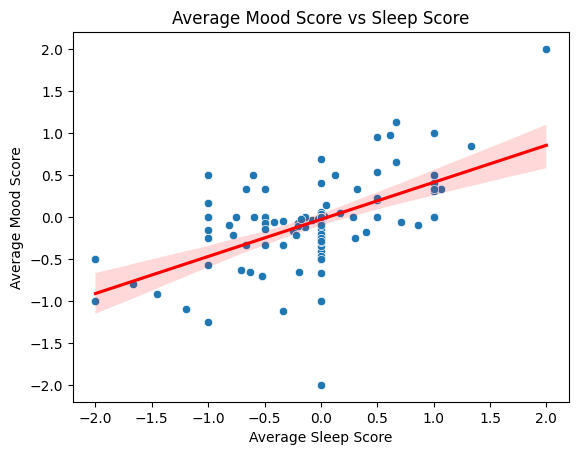

In [52]:
sns.scatterplot(x='how_sleep', y='how_mood', data=sleep_mood_df)
sns.regplot(x='how_sleep', y='how_mood', data=sleep_mood_df, scatter=False, color='red')
plt.xlabel('Average Sleep Score')
plt.ylabel('Average Mood Score')
plt.title('Average Mood Score vs Sleep Score')
plt.show()

<h3>Further Steps</h3>
<p>The next steps would be to further clean data as each column was not explored in depth, and to appropriately analyze the relationships of features within the dataset and recognize any patterns that may exist within and to possibly create a feature that could assist in the performance of the predictive model.</p>